### MECE
#### Task Allocation with Evaluation Tracking  

| Student | Task                          | Status  | Baseline Metrics (AUC/Accuracy) | Improved Metrics (After Tuning) | Comments |
|---------|-------------------------------|---------|----------------------------------|----------------------------------|----------|
| Clifford Addison | **Preprocessing & Feature Engineering** | Pending |  |  | |
| Kauthara Oyinkansola Yakubu   | **CNN Model Building + Tuning** | Pending | Input Your Accuracy Values here |  | |
| Shahnaz Palakunnil Moosa   | **SVM Model Building** | Pending | Input Your Accuracy Values here |  | |
| Mansi Jayeshbhai Sutreja  | **KNN Model Building + Tuning** | Pending | Input Your Accuracy Values here |  | |
| Abdullah Mohammed Ifteqar   | **DNN Model Building + Tuning** | Pending | Input Your Accuracy Values here |  | |
| Saurav Risal   | **CNN Model Tuning x 2** | Pending |  | Input Your Accuracy Values here | |
| Siddhi Pravinbhai Patel   | **KNN Model Tuning x 2** | Pending |  | Input Your Accuracy Values here | |
| Utsav Harshadbhai Khamar   | **DNN Model Tuning x 2** | Pending |  | Input Your Accuracy Values here | |
| Obianuju Nonyerem Anuma | **LIME Interpretability** | Pending |  |  | |

## 1. Preprocessing & Feature Engineering
- Fetch/clean Yelp images.
- Resize (224x224), normalize, augment.
- Extract HOG/SIFT features for SVM/KNN.

### Deliverable
- Cleaned dataset, augmented images, feature matrices.

*NB: MAKE SURE TO ADD COMMENTS (NEGATIVE MARKS FOR NO COMMENTS)*


In [83]:
# Necessary Libraries
import pandas as pd
import numpy as np
import json
import os
import random
import shutil
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import matplotlib.pyplot as plt

import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")

In [84]:
# Load the photos JSON file
photos_df = pd.read_json(r"C:\Users\utsav\Downloads\Yelp Photos\photos.json", lines=True)

In [85]:
# Check the head of the dataframe
photos_df.head()

,photo_id,business_id,caption,label
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food


In [86]:
# Check the info of the dataframe
photos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


In [87]:
# Check the labels of the photos
photos_df['label'].unique()

array(['inside', 'outside', 'drink', 'food', 'menu'], dtype=object)

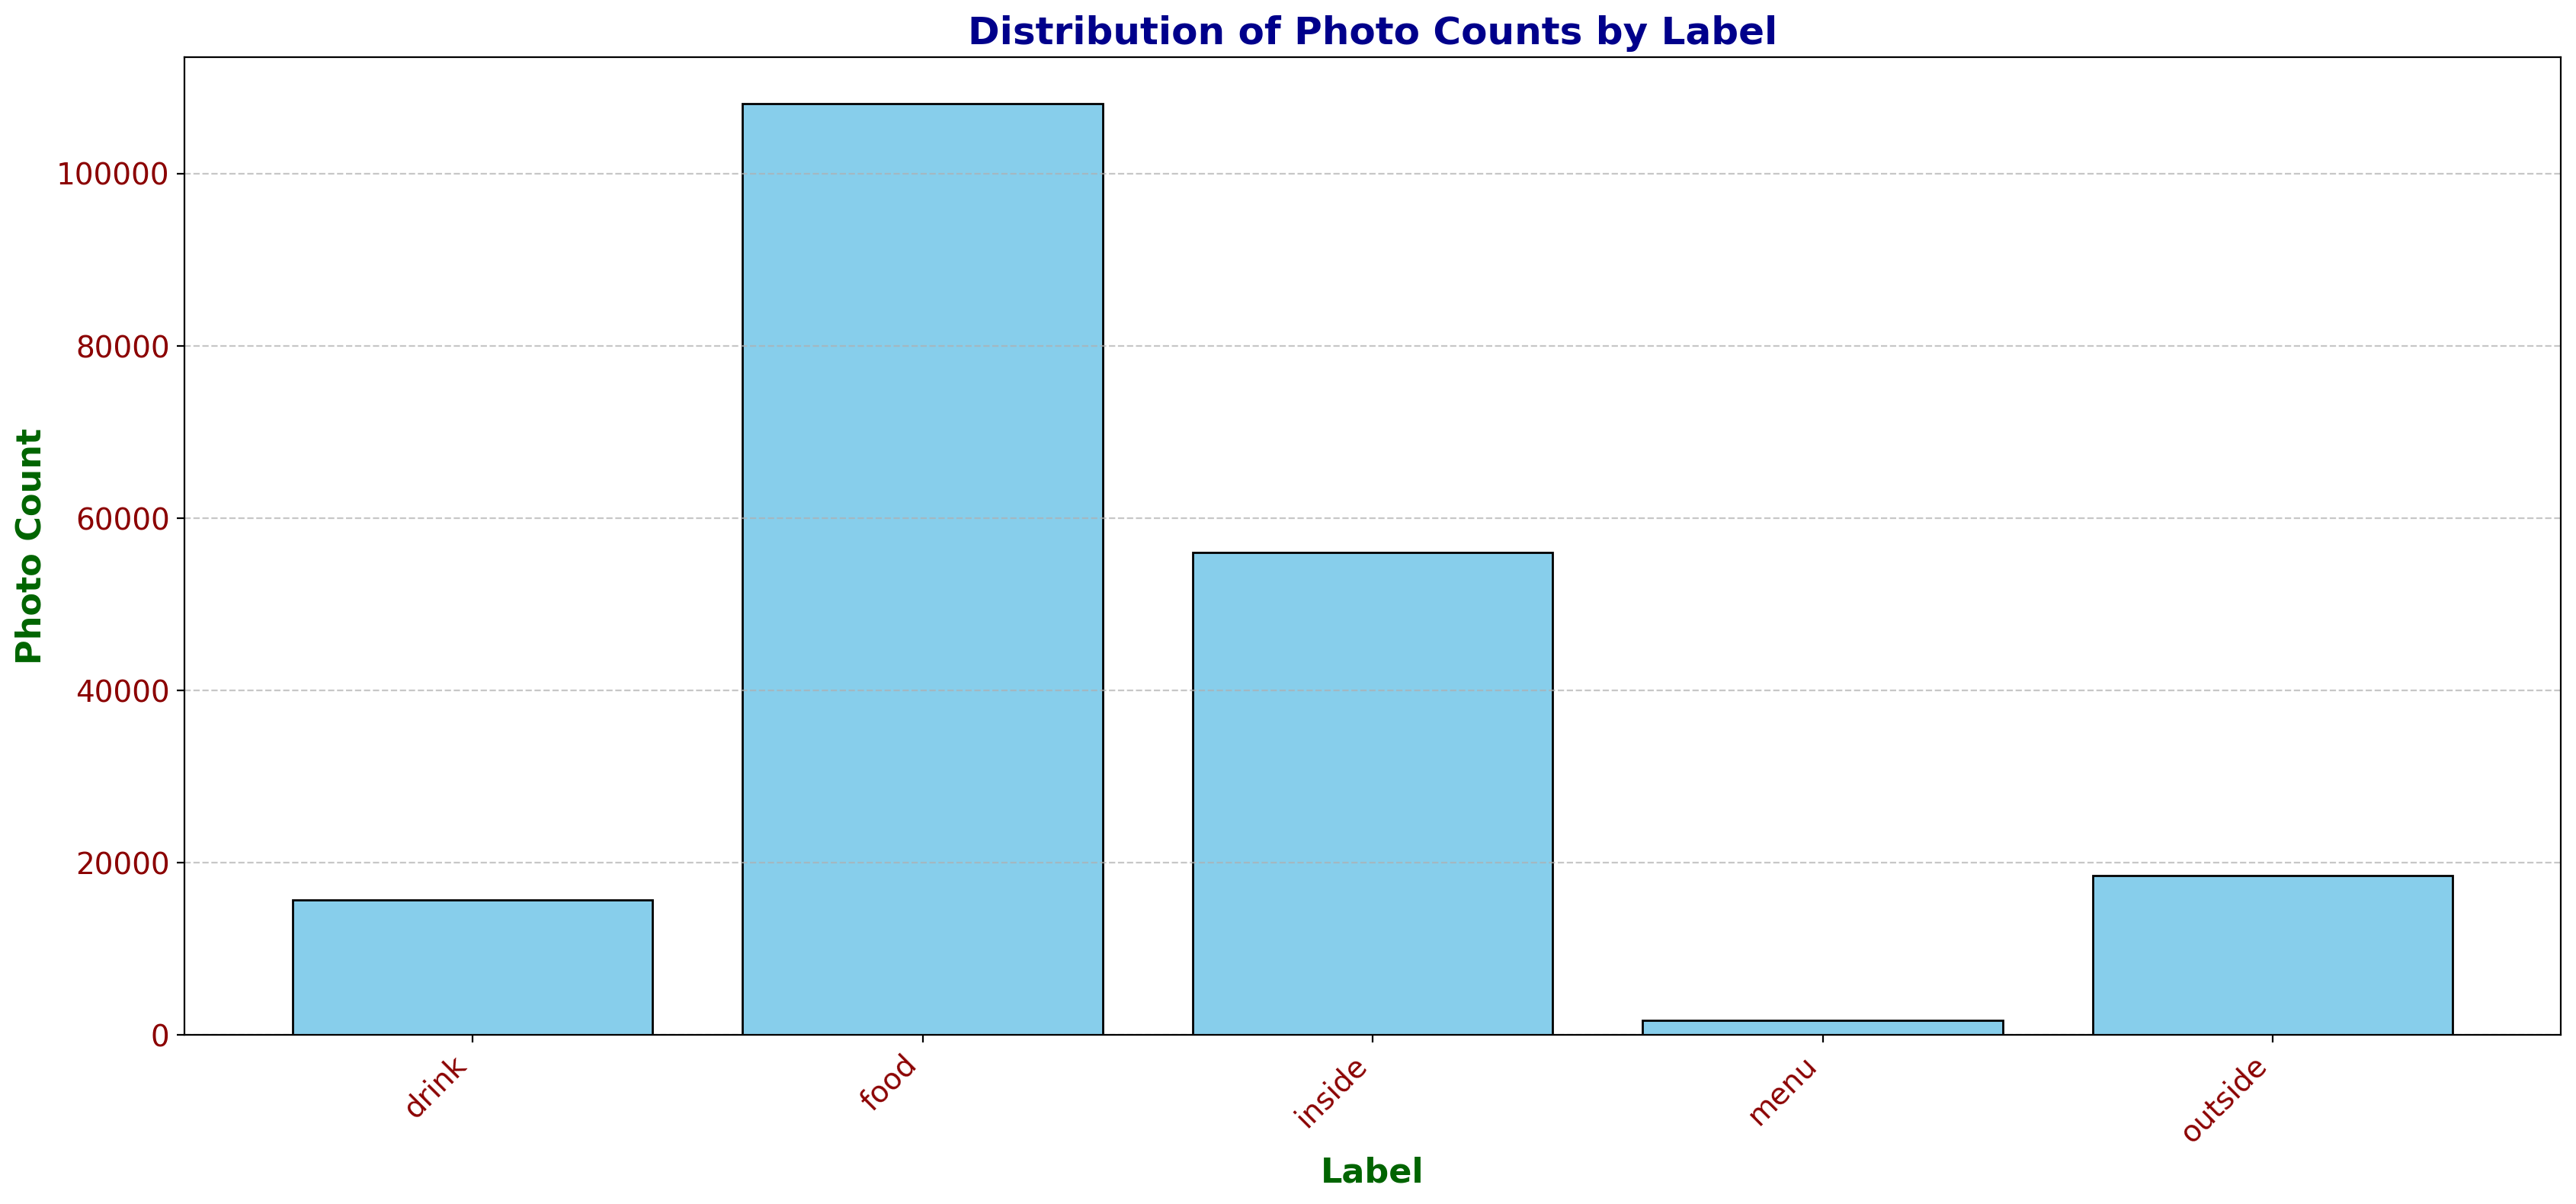

In [88]:
# Group data and prepare for plotting
label_counts = photos_df.groupby('label')['photo_id'].count().reset_index()

# Plot
plt.figure(figsize=(17, 8), dpi=200)
plt.bar(label_counts['label'], label_counts['photo_id'], color='skyblue', edgecolor='black')
plt.title("Distribution of Photo Counts by Label", fontsize=18, fontweight='bold', color='darkblue')
plt.xlabel("Label", fontsize=16, fontweight='bold', color='darkgreen')
plt.ylabel("Photo Count", fontsize=16, fontweight='bold', color='darkgreen')
plt.xticks(fontsize=14, rotation=45, ha='right', color='darkred')
plt.yticks(fontsize=14, color='darkred')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()

In [89]:
# Count the total number of photos with the label "drink"
drink_count = photos_df[photos_df['label'] == 'drink']['photo_id'].count()

print(f"Total number of photos with label 'drink': {drink_count}")

Total number of photos with label 'drink': 15670


In [90]:
# Count the total number of photos with the label "drink"
food_count = photos_df[photos_df['label'] == 'food']['photo_id'].count()

print(f"Total number of photos with label 'food': {food_count}")

Total number of photos with label 'food': 108152


In [91]:
# Count the total number of photos with the label "drink"
inside_count = photos_df[photos_df['label'] == 'inside']['photo_id'].count()

print(f"Total number of photos with label 'inside': {inside_count}")

Total number of photos with label 'inside': 56031


In [92]:
# Count the total number of photos with the label "menu"
menu_count = photos_df[photos_df['label'] == 'menu']['photo_id'].count()

print(f"Total number of photos with label 'menu': {menu_count}")

Total number of photos with label 'menu': 1678


In [93]:
# Count the total number of photos with the label "drink"
outside_count = photos_df[photos_df['label'] == 'outside']['photo_id'].count()

print(f"Total number of photos with label 'outside': {outside_count}")

Total number of photos with label 'outside': 18569


In [94]:
# Balanced Random Sampling (equal class representation)
np.random.seed(42)  
sample_size = 1678  # Based on your smallest class ('menu')
balanced_sample = (
    photos_df
    .groupby('label', group_keys=False)
    .apply(lambda x: x.sample(n=min(sample_size, len(x)), random_state=np.random.randint(0, 1000)))
    .reset_index(drop=True)
)

In [95]:
# Check label counts
print(balanced_sample['label'].value_counts())

label
drink      1678
food       1678
inside     1678
menu       1678
outside    1678
Name: count, dtype: int64


In [96]:
# Create 'photo_path' column by appending '.jpg' to 'photo_id'
balanced_sample['photo_path'] = balanced_sample['photo_id'].astype(str) + '.jpg'

In [97]:
balanced_sample

,photo_id,business_id,caption,label,photo_path
0,KG5NtAHZM26FesRc8SoGoA,JUVtr9lqM1dCaiLPFPCeBw,,drink,KG5NtAHZM26FesRc8SoGoA.jpg
1,g2fXpw6cM7Z2DqPjVlBrqw,6LA1ttZl3vLl3YBg4IqZWw,,drink,g2fXpw6cM7Z2DqPjVlBrqw.jpg
2,EyUtVxXnCUzJedhCRu12dw,jhKnKBjNTfg5PAlQilwVcA,,drink,EyUtVxXnCUzJedhCRu12dw.jpg
3,OVJ9XkUbG7hyJBJxnoN85A,B6-GVRwT6tv8V30tz5jxqw,,drink,OVJ9XkUbG7hyJBJxnoN85A.jpg
4,A0UhOmtX2HniqLiiCsIRgA,SkEr3iGr9x5aw7Dh5bOtxg,Spices,drink,A0UhOmtX2HniqLiiCsIRgA.jpg
...,...,...,...,...,...
8385,yv0H8SkD6_2AeBFl1YM9Aw,zfz6rU6bIE6CnKdsQadklA,,outside,yv0H8SkD6_2AeBFl1YM9Aw.jpg
8386,iMpAlVpHnJBSyMUfXC_nfQ,L5LLN0RafiV1Z9cddzvuCw,,outside,iMpAlVpHnJBSyMUfXC_nfQ.jpg
8387,gHC9xT61HyThSgxbxLfYXg,whmn0dUpEb2NbmpVF2Xxcw,,outside,gHC9xT61HyThSgxbxLfYXg.jpg
8388,P0ogHm58DqP7L1ApbmrMRw,iSRTaT9WngzB8JJ2YKJUig,,outside,P0ogHm58DqP7L1ApbmrMRw.jpg


In [98]:
# Set random seed for reproducibility
random.seed(42)

# Get 2 samples per label with .jpg extension
photo_samples = (
    balanced_sample
    .groupby('label', as_index=False)
    .apply(lambda x: x.sample(n=2, random_state=42) if len(x) >= 2 else x)  # Sample 2 or fewer if not enough
    .reset_index(drop=True) 
)

# Append the extension ".jpg" to the photo_path
photo_samples['photo_path'] = photo_samples['photo_id'] + '.jpg'

# Convert to list of dictionaries for easy display
sample_list = photo_samples.to_dict('records')

# Display the samples
print("Sample photos to display (2 per label):")
for item in sample_list:
    print(f"{item['label']}: {item['photo_path']}")

# Store just the paths in a separate list if needed
photo_paths_list = photo_samples['photo_path'].tolist()

Sample photos to display (2 per label):
drink: xQHnU9kJgso76snNoMNjug.jpg
drink: eOeOg6SQodZ6JcU-i-lsBA.jpg
food: XJF59gjUD4uLk7V4lnCbTw.jpg
food: zxgeIq26HH1EWJzNMigEjA.jpg
inside: iMnSbolOsZSqEXOrAz1f9Q.jpg
inside: s78KhjjaMZV81LpSB6xyhQ.jpg
menu: g8Tny5EySXaBCNPwHYCHYA.jpg
menu: NTigE8kDbWvadDHu-E6PCQ.jpg
outside: Khlgl_PbF1xVxhRPveJZoA.jpg
outside: vXInY7lWM_gbnJS6DaniYA.jpg


In [99]:
photo_paths_list

['xQHnU9kJgso76snNoMNjug.jpg',
 'eOeOg6SQodZ6JcU-i-lsBA.jpg',
 'XJF59gjUD4uLk7V4lnCbTw.jpg',
 'zxgeIq26HH1EWJzNMigEjA.jpg',
 'iMnSbolOsZSqEXOrAz1f9Q.jpg',
 's78KhjjaMZV81LpSB6xyhQ.jpg',
 'g8Tny5EySXaBCNPwHYCHYA.jpg',
 'NTigE8kDbWvadDHu-E6PCQ.jpg',
 'Khlgl_PbF1xVxhRPveJZoA.jpg',
 'vXInY7lWM_gbnJS6DaniYA.jpg']

In [100]:
#photos_folder = './balanced_photos_folder'
photos_folder = r"C:\Users\utsav\Downloads\balanced_photos_folder"

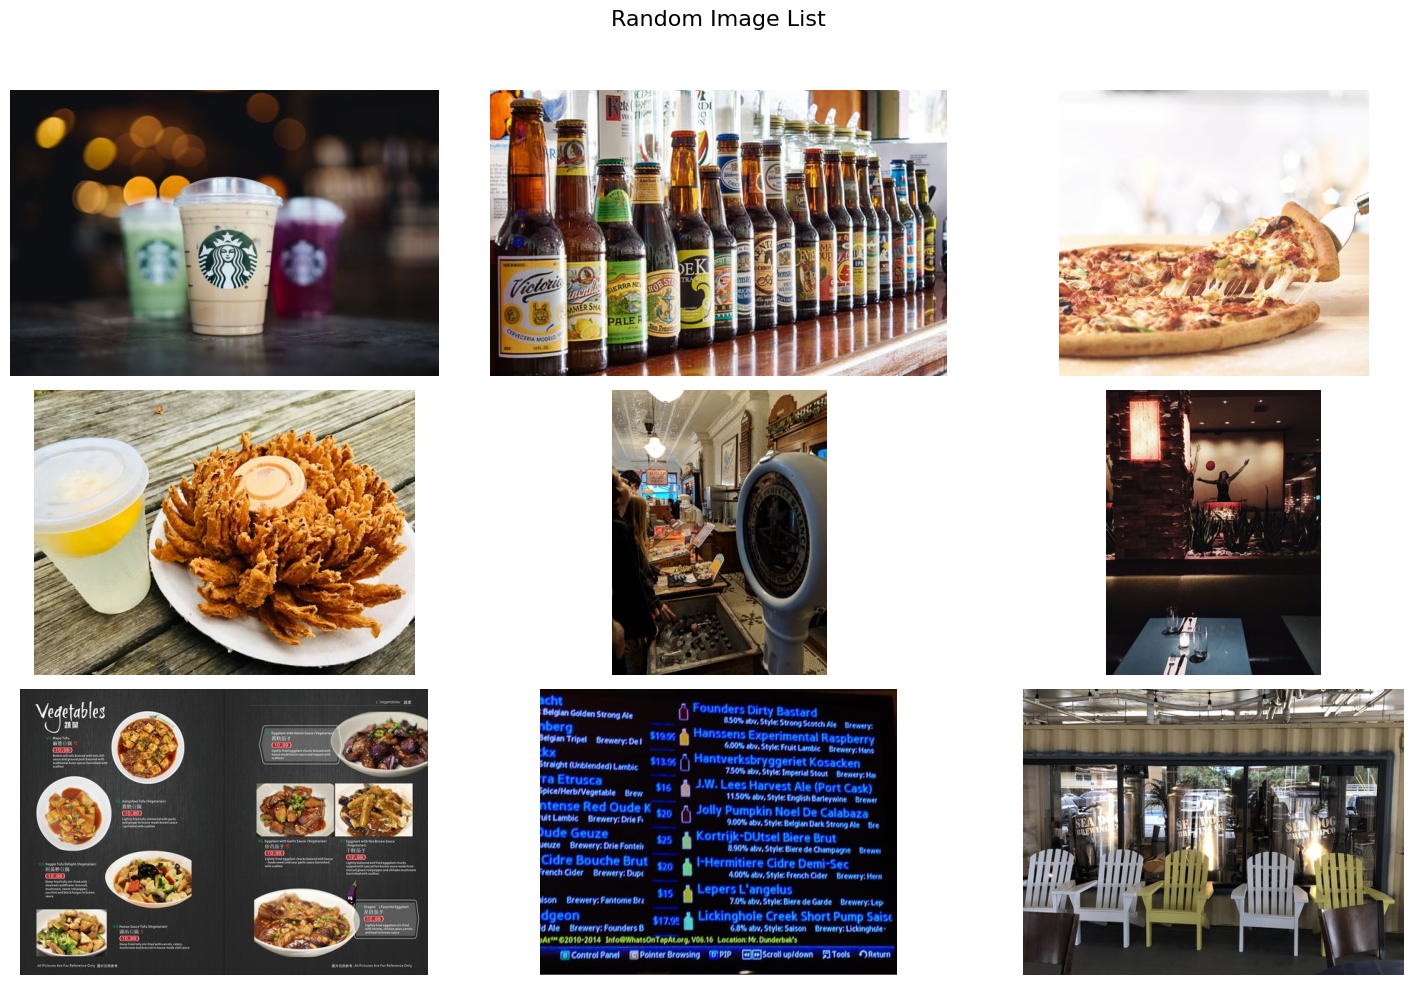

In [101]:
# Display the sampled photos
fig = plt.figure(figsize=(15, 10))
fig.suptitle("Random Image List", fontsize=16)

# Limit to the first 9 images
for i, photo in enumerate(sample_list[:9]):  # Only take the first 9 samples
    img_path = os.path.join(photos_folder, photo['photo_path'])  # Extract 'photo_path' from the dictionary
    img = Image.open(img_path)
    
    # Create a subplot for each image
    ax = fig.add_subplot(3, 3, i + 1)  # 3 rows, 3 columns
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Adjust title position
plt.show()

### Image Preprocessing

#### Resizing

In [102]:
# Define resizing parameters for photos
IMG_SIZE_CNN_DNN = (224, 224)
IMG_SIZE_SVM_KNN = (64, 64)

In [103]:
# Initialize empty lists to store images and labels for CNN/DNN and SVM/kNN
cnn_images, dnn_images, svm_knn_images, labels = list(), [], [], []

In [104]:
# Iterate through each row in the balanced sample to process images
for _, row in balanced_sample.iterrows():
    photo_id = row['photo_id']
    label = row['label']
    img_path = os.path.join(photos_folder, f"{photo_id}.jpg")

    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        if img is None:
            continue

        # CNN/DNN
        resized_cnn = cv2.resize(img, IMG_SIZE_CNN_DNN)
        cnn_images.append(resized_cnn)  # Normalized later
        dnn_images.append(resized_cnn)  # Same as CNN but flattened later

        # SVM/kNN
        resized_svm = cv2.resize(img, IMG_SIZE_SVM_KNN)
        svm_knn_images.append(resized_svm)

        labels.append(label)

In [105]:
# Convert lists of images and labels to NumPy arrays for further processing
cnn_images = np.array(cnn_images)
dnn_images = np.array(dnn_images)
svm_knn_images = np.array(svm_knn_images)
labels = np.array(labels)

In [106]:
# Train-test split BEFORE label encoding
X_train_cnn, X_test_cnn, y_train_cnn_raw, y_test_cnn_raw = train_test_split(
    cnn_images, labels, test_size=0.3, stratify=labels, random_state=42)

X_train_dnn, X_test_dnn, y_train_dnn_raw, y_test_dnn_raw = train_test_split(
    dnn_images, labels, test_size=0.3, stratify=labels, random_state=42)

X_train_svm_knn, X_test_svm_knn, y_train_svm_knn_raw, y_test_svm_knn_raw = train_test_split(
    svm_knn_images, labels, test_size=0.3, stratify=labels, random_state=42)

In [107]:
# Fit LabelEncoder on CNN training set
label_enc = LabelEncoder()
y_train_cnn = label_enc.fit_transform(y_train_cnn_raw)
y_test_cnn = label_enc.transform(y_test_cnn_raw)

In [108]:
# Fit LabelEncoder on DNN training set
y_train_dnn = label_enc.fit_transform(y_train_dnn_raw)  # same encoder!
y_test_dnn = label_enc.transform(y_test_dnn_raw)

In [109]:
# Fit LabelEncoder on SVM & kNN training set
y_train_svm_knn = label_enc.fit_transform(y_train_svm_knn_raw)
y_test_svm_knn = label_enc.transform(y_test_svm_knn_raw)

In [110]:
# Function to normalize the CNN training and test data
def normalize_in_batches(X, batch_size=500):
    normalized = []
    for i in range(0, len(X), batch_size):
        batch = X[i:i+batch_size].astype('float32') / 255.0
        normalized.append(batch)
    return np.concatenate(normalized, axis=0)

In [111]:
# Normalize the training and test data for CNN
X_train_cnn = normalize_in_batches(X_train_cnn)
X_test_cnn = normalize_in_batches(X_test_cnn)

In [112]:
# Preprocess for DNN
X_train_dnn = X_train_dnn.reshape(len(X_train_dnn), -1) / 255.0
X_test_dnn = X_test_dnn.reshape(len(X_test_dnn), -1) / 255.0

In [113]:
# Preprocess for SVM/kNN
X_train_svm_knn = X_train_svm_knn.reshape(len(X_train_svm_knn), -1)
X_test_svm_knn = X_test_svm_knn.reshape(len(X_test_svm_knn), -1)

In [114]:
# Standardize the training and test data for SVM and kNN models
scaler = StandardScaler()
X_train_svm_knn = scaler.fit_transform(X_train_svm_knn)
X_test_svm_knn = scaler.transform(X_test_svm_knn)

In [115]:
# Print the shape of CNN train and test splits
print("CNN Model:")
print(f"X_train_cnn shape: {X_train_cnn.shape}")
print(f"X_test_cnn shape: {X_test_cnn.shape}")
print(f"y_train_cnn shape: {y_train_cnn.shape}")
print(f"y_test_cnn shape: {y_test_cnn.shape}")

CNN Model:
X_train_cnn shape: (5870, 224, 224, 3)
X_test_cnn shape: (2517, 224, 224, 3)
y_train_cnn shape: (5870,)
y_test_cnn shape: (2517,)


In [116]:
# Print the shape of DNN train and test splits
print("DNN Model:")
print(f"X_train_dnn shape: {X_train_dnn.shape}")
print(f"X_test_dnn shape: {X_test_dnn.shape}")
print(f"y_train_dnn shape: {y_train_dnn.shape}")
print(f"y_test_dnn shape: {y_test_dnn.shape}")

DNN Model:
X_train_dnn shape: (5870, 150528)
X_test_dnn shape: (2517, 150528)
y_train_dnn shape: (5870,)
y_test_dnn shape: (2517,)


In [117]:
# Print the shape of SVM/kNN train and test splits
print("SVM/KNN Model:")
print(f"X_train_svm_knn shape: {X_train_svm_knn.shape}")
print(f"X_test_svm_knn shape: {X_test_svm_knn.shape}")
print(f"y_train_svm_knn shape: {y_train_svm_knn.shape}")
print(f"y_test_svm_knn shape: {y_test_svm_knn.shape}")

SVM/KNN Model:
X_train_svm_knn shape: (5870, 12288)
X_test_svm_knn shape: (2517, 12288)
y_train_svm_knn shape: (5870,)
y_test_svm_knn shape: (2517,)


Prompt Used:
* **LLM Used:** DeepSeek
* **First Prompt:** I have a Yelp photos dataset I want you to list the necessary preprocessing steps I will need to complete a Computer Vision project.
* **Last Prompt:** Is it necessary to implement Intensity Thresholding and Gaussian Blur for CNN, DNN, SVM and kNN on the Yelp Photos dataset?

## 5. DNN Model Building+ 1 Hyperparameter Tuning
- Build 3-layer MLP (ReLU, dropout).
- Baseline evaluation.

### Deliverable
- Trained DNN model + evaluation metrics.

*NB: MAKE SURE TO ADD COMMENTS (NEGATIVE MARKS FOR NO COMMENTS)*

In [118]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,PReLU,BatchNormalization

"""
Creating a ANN model with 3 layers
with 128, 64, 32, nurons in layers.
I am using prelu for activation fiunctions to improve the accurecy as ANN dont ideally work for images
and prelu has non zero value.
Also I am using adam as default optimizer and 0.001 as the learning rate
"""

def create_ann_model(input_dim, 
    output_dim, 
    hidden1=128, 
    hidden2=64, 
    hidden3=32, 
    optimizer='adam', 
    learning_rate=0.001):
    """
    Create a 5-layer dense ANN with PReLU and BatchNormalization layers.
    input_dim: integer size of input vector
    Returns compiled keras model
    """
    model = Sequential()
    
    # Input layer
    model.add(Dense(hidden1, input_shape=(input_dim,)))
    model.add(PReLU())
    model.add(BatchNormalization())
    
    # Hidden layers
    model.add(Dense(hidden2))
    model.add(PReLU())
    model.add(BatchNormalization())
    
    model.add(Dense(hidden3))
    model.add(PReLU())
    model.add(BatchNormalization())
    
    # Output layer
    model.add(Dense(output_dim, activation='softmax'))
    
    # Optimizer configuration
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = SGD(learning_rate=learning_rate)
    
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [119]:
from tensorflow.keras.utils import to_categorical

# We had label encoded data for the categories
#Converting the labels to one hot encoding to use in classification model and later used the argmax to determine the label encoded ranks
def one_hot_encode(y_train):
    num_classes = len(np.unique(y_train))  # Number of unique classes
    return to_categorical(y_train, num_classes=len(np.unique(y_train)))

#Training the model
def train_model(x_train, y_train, epochs=10, batch_size=32):
    print(f"Dataset loaded: {x_train.shape[1]} samples, input shape {x_train.shape[1:]}")
    y_train_encoded = one_hot_encode(y_train)
    model = create_ann_model(x_train.shape[1], y_train_encoded.shape[1])
    print("Starting training...")
    model.fit(x_train, y_train_encoded, epochs=epochs, batch_size=batch_size, verbose=2)
    print("Training completed.")
    return model

In [120]:
y_train_dnn.shape

(5870,)

In [121]:
dnn_model = train_model(X_train_dnn,y_train_dnn,20,50)

Dataset loaded: 150528 samples, input shape (150528,)
Starting training...
Epoch 1/20
118/118 - 25s - 211ms/step - accuracy: 0.4661 - loss: 1.3529
Epoch 2/20
118/118 - 13s - 112ms/step - accuracy: 0.5501 - loss: 1.1336
Epoch 3/20
118/118 - 13s - 111ms/step - accuracy: 0.5928 - loss: 1.0405
Epoch 4/20
118/118 - 11s - 96ms/step - accuracy: 0.6296 - loss: 0.9613
Epoch 5/20
118/118 - 21s - 176ms/step - accuracy: 0.6627 - loss: 0.8772
Epoch 6/20
118/118 - 21s - 179ms/step - accuracy: 0.7034 - loss: 0.8038
Epoch 7/20
118/118 - 12s - 99ms/step - accuracy: 0.7308 - loss: 0.7258
Epoch 8/20
118/118 - 11s - 92ms/step - accuracy: 0.7596 - loss: 0.6538
Epoch 9/20
118/118 - 22s - 190ms/step - accuracy: 0.7903 - loss: 0.5772
Epoch 10/20
118/118 - 13s - 107ms/step - accuracy: 0.8286 - loss: 0.4869
Epoch 11/20
118/118 - 12s - 103ms/step - accuracy: 0.8344 - loss: 0.4712
Epoch 12/20
118/118 - 13s - 107ms/step - accuracy: 0.8634 - loss: 0.3955
Epoch 13/20
118/118 - 21s - 178ms/step - accuracy: 0.8857 - l

In [122]:
y_pred_dnn = dnn_model.predict(X_test_dnn)  # getting predictions for test data

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step


In [123]:
y_pred_dnn_final = np.argmax(y_pred_dnn, axis=1) # Convert predictions to classes

In [124]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
import seaborn as sns


In [125]:
print("Accuracy:", accuracy_score(y_test_dnn, y_pred_dnn_final))
print("Classification Report:\n", classification_report(y_test_dnn, y_pred_dnn_final))

Accuracy: 0.4620580055621772
Classification Report:
               precision    recall  f1-score   support

           0       0.39      0.30      0.34       504
           1       0.52      0.36      0.42       503
           2       0.39      0.67      0.50       503
           3       0.48      0.55      0.52       504
           4       0.61      0.43      0.50       503

    accuracy                           0.46      2517
   macro avg       0.48      0.46      0.46      2517
weighted avg       0.48      0.46      0.46      2517



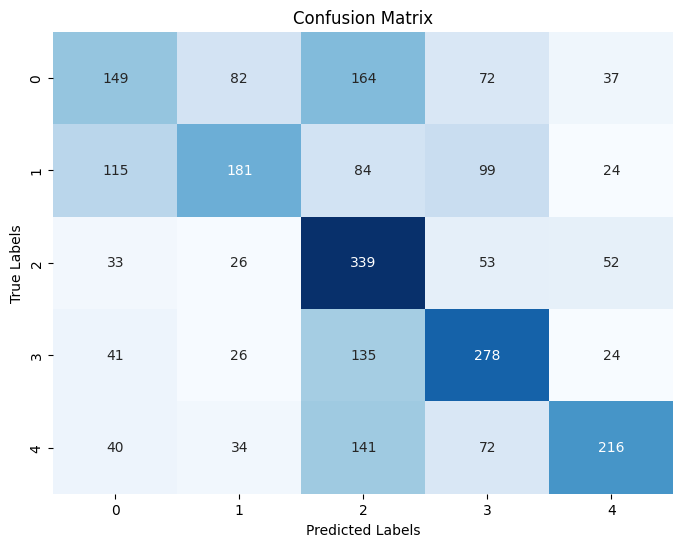

In [126]:
cm = confusion_matrix(y_test_dnn, y_pred_dnn_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

### My observations

The model do not perform too well,There is some level of over fitting as after 20 epocs train accuracy is 84%
and test accuracy is around 45%

Planning to tune based on epocs, no of neurons and learning rates to help with overfitting

Finally if it still doesnot help Number of hidden layers can be reduced.

Prompt Used:
* LLM Used: ChatGPT
* First Prompt: How to unzip rar file in google colab
* Last Prompt: how to convert label classes to onehot and ANN one hot classes to label classes

## HyperParameter Tuning - DNN

In [130]:
#Importing the neccessary libraries

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, PReLU, BatchNormalization
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
import keras_tuner as kt   # For hyperparameter tuning
import tensorflow as tf
from tensorflow.keras.utils import to_categorical   # For one-hot encoding


# Set input dimension from the test dataset shape
input_dim = X_test_dnn.shape[1]

# Convert training and testing labels to one-hot encoded format
y_train_dnn_final = to_categorical(y_train_dnn, num_classes=len(np.unique(y_train_dnn)))
y_test_dnn_final = to_categorical(y_test_dnn, num_classes=len(np.unique(y_test_dnn)))

# here the output dimension is the number of unique classes
output_dim = y_train_dnn_final.shape[1]

def build_tunable_model(hp):
    model = Sequential()
    
    # Tunable input layer
    model.add(Dense(
        units=hp.Int('hidden1', min_value=64, max_value=256, step=32),
        input_shape=(input_dim,)
    ))
    model.add(PReLU())
    model.add(BatchNormalization())
    
    # Tunable hidden layers
    model.add(Dense(
        units=hp.Int('hidden2', min_value=32, max_value=128, step=16)
    ))
    model.add(PReLU())
    model.add(BatchNormalization())
    
    model.add(Dense(
        units=hp.Int('hidden3', min_value=16, max_value=64, step=8)
    ))
    model.add(PReLU())
    model.add(BatchNormalization())
    
    # Output layer
    model.add(Dense(output_dim, activation='softmax'))
    
    # Tunable optimizer and learning rate
    optimizer = hp.Choice('optimizer', ['adam', 'rmsprop', 'sgd'])
    lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    
    if optimizer == 'adam':
        opt = Adam(learning_rate=lr)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=lr)
    else:
        opt = SGD(learning_rate=lr)
    
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model



In [131]:
# Initialize tuner
tuner = kt.Hyperband(
    build_tunable_model,
    objective='val_accuracy',
    max_epochs=50,
    factor=3,
    directory='keras_tuner',
    project_name='ann_tuning'
)

# Early stopping callback
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# Run the search
tuner.search(
    X_train_dnn, y_train_dnn_final,
    validation_split=0.2,  # Uses 20% of training data for validation
    epochs=100,
    callbacks=[early_stop],
    batch_size=64
)

# Get best model and hyperparameters
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Best Hyperparameters:
- hidden1: {best_hps.get('hidden1')}
- hidden2: {best_hps.get('hidden2')}
- hidden3: {best_hps.get('hidden3')}
- optimizer: {best_hps.get('optimizer')}
- learning_rate: {best_hps.get('learning_rate')}
""")

# Evaluate on test set
test_loss, test_acc = best_model.evaluate(X_test_dnn, y_test_dnn_final)
print(f"\nTest Accuracy: {test_acc:.4f}")

Reloading Tuner from keras_tuner\ann_tuning\tuner0.json

Best Hyperparameters:
- hidden1: 256
- hidden2: 32
- hidden3: 24
- optimizer: sgd
- learning_rate: 0.00014960163610305998

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.4996 - loss: 1.3402

Test Accuracy: 0.4962


79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.4996 - loss: 1.3402

Test Accuracy: 0.4962
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.30      0.38       504
           1       0.51      0.59      0.55       503
           2       0.42      0.49      0.45       503
           3       0.61      0.51      0.56       504
           4       0.47      0.59      0.53       503

    accuracy                           0.50      2517
   macro avg       0.50      0.50      0.49      2517
weighted avg       0.50      0.50      0.49      2517



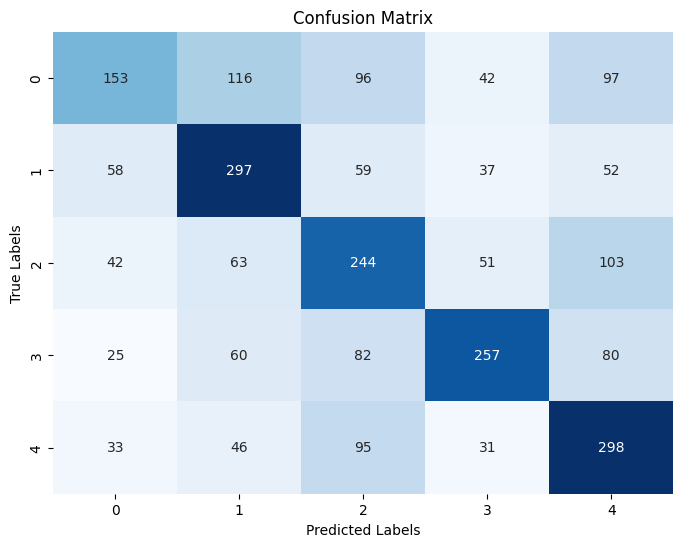

In [129]:
# Save model
best_model.save("best_dnn_model.h5")

# Evaluate model
test_loss, test_acc = best_model.evaluate(X_test_dnn, y_test_dnn_final)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Predict and generate report
y_pred_probs = best_model.predict(X_test_dnn)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_test_dnn_final, axis=1)

print("Classification Report:")
print(classification_report(y_true_labels, y_pred_labels))

# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [134]:
from itertools import cycle
def plot_multiclass_roc(y_true, y_score, title='ROC Curve'):
    # Number of classes
    n_classes = y_true.shape[1]

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])
    plt.figure(figsize=(10, 8))
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='Class {0} (AUC = {1:0.2f})'.format(i, roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step


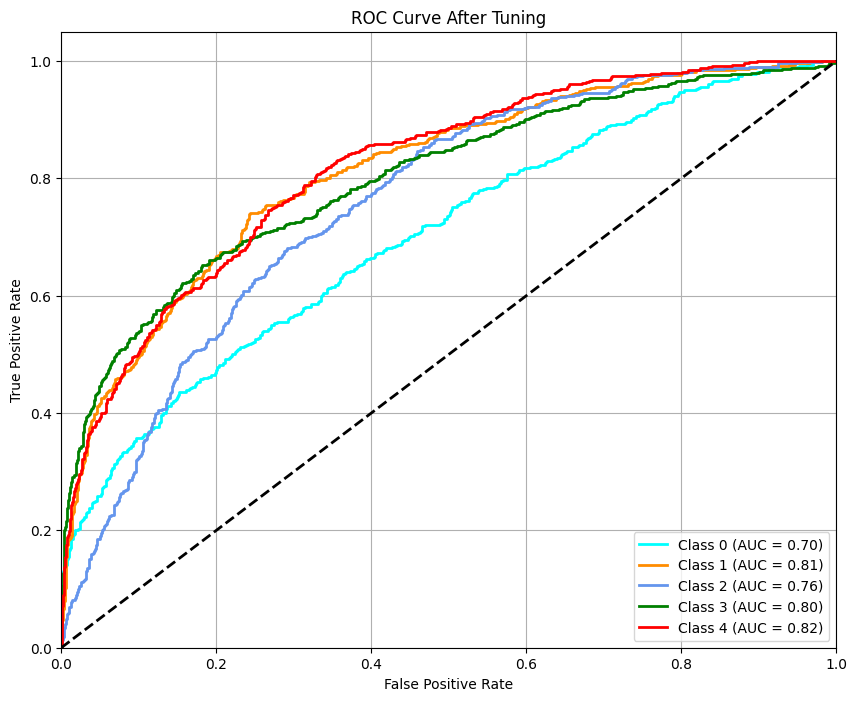

In [135]:
# Get predicted probabilities from the best model
y_score_after = best_model.predict(X_test_dnn)

# Plot ROC curve after tuning
plot_multiclass_roc(y_test_dnn_final, y_score_after, title='ROC Curve After Tuning')


Key Findings:

- the model is not generalizing well across all classes.
- The model has not learned meaningful features beyond chance-level performance (~50% for 5 classes is just above random guess).
- Recall is poor for Class 0, suggesting the model consistently fails to identify samples from this class.

LLM Prompts:

- how to install tensorflow in virtual env
- calculate the iterations of my hyperparameter tuning might take

